
# 3. Model

> **Data:** `cleaned_EDA_ready_timeseries.csv`


In [39]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from pmdarima import auto_arima
from copy import deepcopy
from sklearn.impute import SimpleImputer

plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['axes.grid'] = True

DATA_PATH = "cleaned_EDA_ready_timeseries.csv"  
TARGET = "CO2_total_mt"
CORE_FEATS = ["GDP_current_usd","Population_total","LifeExp_years","Energy_use_kg_oil_pc","Renewable_energy_pct"]
CUTOFF_YEAR = 2014 
RANDOM_STATE = 42

In [40]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape, "| Years:", f"{df['Year'].min()}–{df['Year'].max()}", "| Countries:", df['Country Name'].nunique())

# basic cleaning
df = df.sort_values(["Country Name","Year"]).reset_index(drop=True)
num_cols = ["Year"] + CORE_FEATS + [TARGET]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# drop rows with null target
df = df.dropna(subset=[TARGET]).copy()
df

Shape: (7830, 14) | Years: 1970–2023 | Countries: 145


,Country Name,Country Code,Year,GDP_current_usd,Population_total,LifeExp_years,Energy_use_kg_oil_pc,Renewable_energy_pct,CO2_total_mt,CO2_per_capita_ton,log1p_GDP_current_usd,log1p_Population_total,log1p_Energy_use_kg_oil_pc,log1p_CO2_total_mt
0,Albania,ALB,1970,1.578102e+09,2135479.0,65.234,813.373801,25.5,4.8450,2.268812,21.179489,14.574202,6.702419,1.765587
1,Albania,ALB,1971,1.578102e+09,2187853.0,65.896,813.373801,25.5,4.8381,2.211346,21.179489,14.598432,6.702419,1.764405
2,Albania,ALB,1972,1.578102e+09,2243126.0,66.526,813.373801,25.5,5.5183,2.460094,21.179489,14.623381,6.702419,1.874614
3,Albania,ALB,1973,1.578102e+09,2296752.0,67.107,813.373801,25.5,4.9519,2.156045,21.179489,14.647007,6.702419,1.783710
4,Albania,ALB,1974,1.578102e+09,2350124.0,67.633,813.373801,25.5,5.3296,2.267795,21.179489,14.669979,6.702419,1.845237
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7825,Zimbabwe,ZWE,2019,2.571566e+10,15271368.0,61.060,412.165419,81.0,11.1692,0.731382,23.970366,16.541490,6.023848,2.498908
7826,Zimbabwe,ZWE,2020,2.686856e+10,15526888.0,61.530,373.557246,84.1,9.0721,0.584283,24.014223,16.558084,5.925745,2.309769
7827,Zimbabwe,ZWE,2021,2.724051e+10,15797210.0,60.135,405.518564,82.4,10.6233,0.672480,24.027971,16.575344,6.007630,2.453012
7828,Zimbabwe,ZWE,2022,3.278966e+10,16069056.0,62.360,416.586875,82.4,10.9630,0.682243,24.213379,16.592406,6.034493,2.481819


> ### **Set up metrics/plotting functions**

In [41]:
def eval_reg(y_true, y_pred, name="model"):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    mape = float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-9))) * 100.0)
    r2   = float(r2_score(y_true, y_pred))
    return {"model": name, "RMSE": rmse, "MAE": mae, "MAPE%": mape, "R2": r2}

def plot_actual_pred(year, y_true, y_pred, title):
    plt.figure(figsize=(9,4))
    plt.plot(year, y_true, label="Actual")
    plt.plot(year, y_pred, label="Pred")
    plt.title(title); plt.xlabel("Year"); plt.ylabel(TARGET)
    plt.legend(); plt.tight_layout(); plt.show()


# **Single-country forecasting**

In [42]:
# Single-fold training/eval for one country and one time-split
def eval_one_fold(train_df, test_df, feat_cols, target_col="CO2_total_mt"):
    if len(train_df) < 5 or len(test_df) < 2:
        return []
    
    ytr = train_df[target_col].values
    yte = test_df[target_col].values

    # Naive last observed (baseline 1)
    yhat_naive = np.repeat(ytr[-1], len(yte))

    # Linear regression (baseline 2)
    Xtr_lin = train_df[["Year"] + feat_cols].values
    Xte_lin = test_df[["Year"] + feat_cols].values
    lin = LinearRegression().fit(Xtr_lin, ytr)
    yhat_lin = lin.predict(Xte_lin)

    # ARIMA (univariate on CO2 only) (Statistical / Time-series)
    arima_uni = auto_arima(ytr,start_p=0, start_q=0,max_p=5, max_q=5, max_d=2,seasonal=False,            
            stepwise=True,information_criterion="aic",suppress_warnings=True,error_action="ignore",trace=False)
    yhat_arima = arima_uni.predict(n_periods=len(yte))

    # ARIMAX (+ exogenous features scaled) (Statistical / Time-series)
    scaler_exo = StandardScaler()
    Xtr_exo = scaler_exo.fit_transform(train_df[feat_cols])
    Xte_exo = scaler_exo.transform(test_df[feat_cols])
    arimax = auto_arima(ytr,X=Xtr_exo,start_p=0, start_q=0,max_p=5, max_q=5, max_d=2,seasonal=False,
                stepwise=True,information_criterion="aic",suppress_warnings=True,error_action="ignore",trace=False)
    yhat_arimax = arimax.predict(n_periods=len(yte), X=Xte_exo)

    # Random Forest (ML model)
    num_features_single = ["Year"] + feat_cols
    prep_single = ColumnTransformer([("num", StandardScaler(), num_features_single),])
    rf_single = Pipeline([("prep", prep_single),("model", RandomForestRegressor(n_estimators=500,
            random_state=RANDOM_STATE,n_jobs=-1))])
    rf_single.fit(train_df[num_features_single], ytr)
    yhat_rf = rf_single.predict(test_df[num_features_single])

    # XGBoost (ML model)
    xgb_single = Pipeline([("prep", deepcopy(prep_single)),("model", XGBRegressor(n_estimators=600,
            max_depth=4,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,
            random_state=RANDOM_STATE,n_jobs=-1,tree_method="hist"))])
    xgb_single.fit(train_df[num_features_single], ytr)
    yhat_xgb = xgb_single.predict(test_df[num_features_single])

    fold_scores = []
    fold_scores.append(eval_reg(yte, yhat_naive,   "NaiveLastObserved"))
    fold_scores.append(eval_reg(yte, yhat_lin,     "Linear+Features"))
    fold_scores.append(eval_reg(yte, yhat_arima,   "ARIMA(univariate)"))
    fold_scores.append(eval_reg(yte, yhat_arimax,  "ARIMAX(+exo)"))
    fold_scores.append(eval_reg(yte, yhat_rf,      "RandomForest"))
    fold_scores.append(eval_reg(yte, yhat_xgb,     "XGBoost"))

    return fold_scores

def evaluate_country_time_cv(df, COUNTRY, feat_cols, target_col="CO2_total_mt",min_train_years=20,test_window=5):

    d = (df[df["Country Name"] == COUNTRY].copy()[["Year", target_col] + feat_cols]
        .dropna(subset=[target_col])
        .sort_values("Year")
        .reset_index(drop=True))

    years = d["Year"].unique()
    folds_scores = []

    for split_idx in range(min_train_years, len(years) - test_window):
        train_year_max  = years[split_idx - 1]
        test_start_year = years[split_idx]
        test_end_year   = years[split_idx + test_window - 1]

        train_df = d[d["Year"] <= train_year_max].copy()
        test_df  = d[(d["Year"] >= test_start_year) & (d["Year"] <= test_end_year)].copy()

        if len(train_df) < min_train_years or len(test_df) < 1:
            continue

        fold_scores = eval_one_fold(train_df, test_df, feat_cols, target_col=target_col)
        if len(fold_scores) == 0:
            continue

        for fs in fold_scores:
            fs["Country"]      = COUNTRY
            fs["TrainYears"]   = f"{int(train_df['Year'].min())}–{int(train_df['Year'].max())}"
            fs["TestYears"]    = f"{int(test_df['Year'].min())}–{int(test_df['Year'].max())}"
            fs["FoldTrainEnd"] = int(train_df['Year'].max())
            fs["FoldTestEnd"]  = int(test_df['Year'].max())

        folds_scores.extend(fold_scores)

    folds_df = pd.DataFrame(folds_scores)

    if len(folds_df) == 0:
        raise ValueError(f"No valid folds for {COUNTRY}. Try lowering min_train_years or test_window.")

    summary_df = (
        folds_df
        .groupby("model")[["RMSE","MAE","MAPE%","R2"]]
        .mean()
        .sort_values("R2", ascending=False)
        .reset_index())

    return summary_df, folds_df

In [43]:
focus_countries = ["United States","China","India","Germany","Thailand","United Kingdom","Saudi Arabia","Russian Federation"]
results_all_countries = []

for COUNTRY in focus_countries:
    d = (df[df["Country Name"] == COUNTRY].copy()
        [["Year", TARGET] + CORE_FEATS]
        .dropna(subset=[TARGET])
        .sort_values("Year")
        .reset_index(drop=True))

    # split train/test by CUTOFF_YEAR
    train = d[d["Year"] <= CUTOFF_YEAR].copy()
    test  = d[d["Year"]  > CUTOFF_YEAR].copy()

    if len(train) == 0 or len(test) == 0:
        print(f"Skipping {COUNTRY}: not enough train/test data.")
        continue

    ytr = train[TARGET].values
    yte = test[TARGET].values

    # Naive baseline (last observed)
    yhat_naive = np.repeat(ytr[-1], len(yte))
    row_naive = eval_reg(yte, yhat_naive, "NaiveLastObserved")

    # Linear regression (baseline)
    Xtr_lin = train[["Year"] + CORE_FEATS].values
    Xte_lin = test[["Year"] + CORE_FEATS].values

    lin = LinearRegression().fit(Xtr_lin, ytr)
    yhat_lin = lin.predict(Xte_lin)
    row_lin = eval_reg(yte, yhat_lin, "Linear+Features")

    # ARIMA (univariate on CO2 only)
    try:
        arima_uni = auto_arima(ytr,seasonal=False,stepwise=True,
            max_p=5, max_q=5, max_d=2,information_criterion="aic",suppress_warnings=True,)
        yhat_arima = arima_uni.predict(n_periods=len(yte))
        row_arima = eval_reg(yte, yhat_arima, "ARIMA(univariate)")
    except Exception as e:
        print(f"[{COUNTRY}] ARIMA failed: {e}")
        row_arima = {"model": "ARIMA(univariate)",
            "RMSE": np.nan,
            "MAE": np.nan,
            "MAPE%": np.nan,
            "R2": np.nan,}

    # ARIMAX (+ exogenous scaled features)
    try:
        scaler_exo = StandardScaler()
        Xtr_exo = scaler_exo.fit_transform(train[CORE_FEATS])
        Xte_exo = scaler_exo.transform(test[CORE_FEATS])

        arimax = auto_arima(ytr,X=Xtr_exo,seasonal=False,stepwise=True,
            max_p=5, max_q=5, max_d=2,information_criterion="aic",suppress_warnings=True,)
        yhat_arimax = arimax.predict(n_periods=len(yte), X=Xte_exo)
        row_arimax = eval_reg(yte, yhat_arimax, "ARIMAX(+exo)")
    except Exception as e:
        print(f"[{COUNTRY}] ARIMAX failed: {e}")
        row_arimax = {"model": "ARIMAX(+exo)",
            "RMSE": np.nan,
            "MAE": np.nan,
            "MAPE%": np.nan,
            "R2": np.nan,}

    # Random Forest (ML model)
    num_features_single = ["Year"] + CORE_FEATS
    prep_single = ColumnTransformer([("num", StandardScaler(), num_features_single),])

    rf_single = Pipeline([("prep", prep_single),("model", RandomForestRegressor(n_estimators=500,
            random_state=RANDOM_STATE,n_jobs=-1,))])

    rf_single.fit(train[num_features_single], ytr)
    yhat_rf_single = rf_single.predict(test[num_features_single])
    row_rf = eval_reg(yte, yhat_rf_single, "RandomForest")

    # XGBoost (ML model)
    xgb_single = Pipeline([("prep", deepcopy(prep_single)),
        ("model", XGBRegressor(n_estimators=600,max_depth=4,
            learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,
            random_state=RANDOM_STATE,n_jobs=-1,tree_method="hist",))])

    xgb_single.fit(train[num_features_single], ytr)
    yhat_xgb_single = xgb_single.predict(test[num_features_single])
    row_xgb = eval_reg(yte, yhat_xgb_single, "XGBoost")

    train_years = f"{int(train['Year'].min())}–{int(train['Year'].max())}"
    test_years  = f"{int(test['Year'].min())}–{int(test['Year'].max())}"

    rows_this_country = [row_naive,row_lin,row_arima,row_arimax,row_rf,row_xgb,]

    for row in rows_this_country:
        rec = row.copy()
        rec["Country"]    = COUNTRY
        rec["TrainYears"] = train_years
        rec["TestYears"]  = test_years

        # tag family
        if rec["model"] in ["NaiveLastObserved", "Linear+Features", "ARIMA(univariate)", "ARIMAX(+exo)"]:
            rec["Family"] = "Statistical / Time-series"
        else:
            rec["Family"] = "Machine Learning"

        results_all_countries.append(rec)
# Final result
results_country_panel = pd.DataFrame(results_all_countries)
display(results_country_panel)

# quick view who wins per country
best_by_country = (results_country_panel
    .sort_values(["Country","R2"], ascending=[True,False])
    .groupby("Country").head(1).reset_index(drop=True))
print("------ Best model per country (by R² on holdout period) ------")
display(best_by_country)

,model,RMSE,MAE,MAPE%,R2,Country,TrainYears,TestYears,Family
0,NaiveLastObserved,421.824149,366.610400,7.718582,-3.087427,United States,1970–2014,2015–2023,Statistical / Time-series
1,Linear+Features,55.614591,50.228343,1.032850,0.928950,United States,1970–2014,2015–2023,Statistical / Time-series
2,ARIMA(univariate),421.824149,366.610400,7.718582,-3.087427,United States,1970–2014,2015–2023,Statistical / Time-series
3,ARIMAX(+exo),456.672764,400.540913,8.391983,-3.790682,United States,1970–2014,2015–2023,Statistical / Time-series
4,RandomForest,384.241512,309.998199,6.571717,-2.391530,United States,1970–2014,2015–2023,Machine Learning
5,XGBoost,338.190184,266.151656,5.655065,-1.627297,United States,1970–2014,2015–2023,Machine Learning
6,NaiveLastObserved,1227.292166,969.341244,7.798641,-1.241419,China,1970–2014,2015–2023,Statistical / Time-series
7,Linear+Features,872.922037,729.676123,5.933473,-0.133908,China,1970–2014,2015–2023,Statistical / Time-series
8,ARIMA(univariate),583.627872,485.086378,3.967098,0.493127,China,1970–2014,2015–2023,Statistical / Time-series
9,ARIMAX(+exo),943.659988,783.820597,6.365822,-0.325129,China,1970–2014,2015–2023,Statistical / Time-series


------ Best model per country (by R² on holdout period) ------


,model,RMSE,MAE,MAPE%,R2,Country,TrainYears,TestYears,Family
0,ARIMA(univariate),583.627872,485.086378,3.967098,0.493127,China,1970–2014,2015–2023,Statistical / Time-series
1,ARIMAX(+exo),46.374166,42.838994,6.192016,0.538797,Germany,1970–2014,2015–2023,Statistical / Time-series
2,ARIMAX(+exo),179.854224,140.378794,5.405062,0.280421,India,1970–2014,2015–2023,Statistical / Time-series
3,RandomForest,77.653942,64.727718,3.430731,0.539492,Russian Federation,1970–2014,2015–2023,Machine Learning
4,NaiveLastObserved,19.844058,16.728767,2.764388,-0.395737,Saudi Arabia,1970–2014,2015–2023,Statistical / Time-series
5,XGBoost,4.953569,3.563596,1.283342,-0.327914,Thailand,1970–2014,2015–2023,Machine Learning
6,Linear+Features,19.375136,14.058844,4.216069,0.700262,United Kingdom,1970–2014,2015–2023,Statistical / Time-series
7,Linear+Features,55.614591,50.228343,1.032850,0.928950,United States,1970–2014,2015–2023,Statistical / Time-series


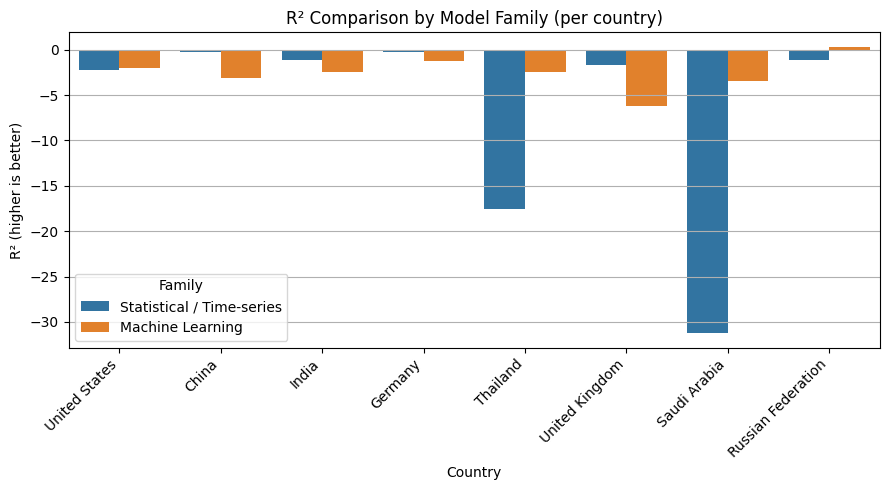

In [45]:
plt.figure(figsize=(9,5))
sns.barplot(data=results_country_panel,x="Country", y="R2", hue="Family",errorbar=None)
plt.title("R² Comparison by Model Family (per country)")
plt.ylabel("R² (higher is better)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# **Cross-country forecasting**

In [46]:
num_features_global = ["Year"] + CORE_FEATS     
cat_features_global = ["Country Code"]                
global_feat_cols = num_features_global + cat_features_global


preprocess_global = ColumnTransformer([("num", Pipeline([("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),]), num_features_global),("cat", OneHotEncoder(handle_unknown="ignore"), cat_features_global),])

def build_rf_global():
    return Pipeline([("prep", preprocess_global),("model", RandomForestRegressor(
            n_estimators=500,random_state=RANDOM_STATE,n_jobs=-1))])

def build_xgb_global():
    return Pipeline([("prep", preprocess_global),("model", XGBRegressor(n_estimators=800,max_depth=6,
            learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,random_state=RANDOM_STATE,n_jobs=-1,tree_method="hist"))])

# baseline
def global_naive_lastobserved(test_df, train_df, target_col, cutoff_year):
    preds = []
    trues = []
    last_by_country = (train_df[train_df["Year"] == cutoff_year].groupby("Country Name")[target_col].last())

    for c, gtest in test_df.groupby("Country Name"):
        if c not in last_by_country.index:
            continue 
        y_true_c = gtest[target_col].values
        y_pred_c = np.repeat(last_by_country.loc[c], len(y_true_c))
        trues.append(y_true_c)
        preds.append(y_pred_c)

    if len(trues) == 0:
        return None

    y_true_all = np.concatenate(trues)
    y_pred_all = np.concatenate(preds)

    return eval_reg(y_true_all, y_pred_all, "Global-NaiveLastObserved")


def global_mean_baseline(test_df, train_df, target_col):
    y_true = test_df[target_col].values
    y_pred = np.repeat(train_df[target_col].mean(), len(y_true))
    return eval_reg(y_true, y_pred, "Global-MeanBaseline")


def evaluate_global_time_cv_all_models(df,target_col,feat_cols,year_folds,horizon=5):

    rows = []
    for cutoff in year_folds:
        train_df = df[df["Year"] <= cutoff].copy()
        test_df  = df[(df["Year"] > cutoff) & (df["Year"] <= cutoff + horizon)].copy()

        if len(train_df) == 0 or len(test_df) < 2:
            print(f"[skip fold <= {cutoff}] not enough data")
            continue

        # Baseline: Global Mean
        row_mean = global_mean_baseline(test_df, train_df, target_col)
        row_mean.update({
            "fold":        f"{cutoff+1}-{cutoff + horizon}",
            "train_years": f"<= {cutoff}",
            "test_years":  f"{cutoff+1}-{cutoff + horizon}",
            "Family":      "Baseline",
            "Countries_test": test_df["Country Name"].nunique(),
            "Rows_test":      len(test_df),})
        rows.append(row_mean)

        # Baseline: Naive Last Observed per Country
        row_naive = global_naive_lastobserved(
            test_df=test_df,
            train_df=train_df,
            target_col=target_col,
            cutoff_year=cutoff)
        
        if row_naive is not None:
            row_naive.update({
                "fold":        f"{cutoff+1}-{cutoff + horizon}",
                "train_years": f"<= {cutoff}",
                "test_years":  f"{cutoff+1}-{cutoff + horizon}",
                "Family":      "Baseline",
                "Countries_test": test_df["Country Name"].nunique(),
                "Rows_test":      len(test_df),})
            rows.append(row_naive)

        # RandomForest Global
        rf_model = build_rf_global()
        X_train_rf = train_df[feat_cols]
        y_train_rf = train_df[target_col].values
        X_test_rf  = test_df[feat_cols]
        y_test_rf  = test_df[target_col].values

        rf_model.fit(X_train_rf, y_train_rf)
        y_pred_rf = rf_model.predict(X_test_rf)
        row_rf = eval_reg(y_test_rf, y_pred_rf, "Global-RandomForestRegressor")
        row_rf.update({
            "fold":        f"{cutoff+1}-{cutoff + horizon}",
            "train_years": f"<= {cutoff}",
            "test_years":  f"{cutoff+1}-{cutoff + horizon}",
            "Family":      "Machine Learning",
            "Countries_test": test_df["Country Name"].nunique(),
            "Rows_test":      len(test_df),})
        rows.append(row_rf)

        # XGBoost Global
        xgb_model = build_xgb_global()
        X_train_xgb = train_df[feat_cols]
        y_train_xgb = train_df[target_col].values
        X_test_xgb  = test_df[feat_cols]
        y_test_xgb  = test_df[target_col].values

        xgb_model.fit(X_train_xgb, y_train_xgb)
        y_pred_xgb = xgb_model.predict(X_test_xgb)
        row_xgb = eval_reg(y_test_xgb, y_pred_xgb, "Global-XGBRegressor")
        row_xgb.update({
            "fold":        f"{cutoff+1}-{cutoff + horizon}",
            "train_years": f"<= {cutoff}",
            "test_years":  f"{cutoff+1}-{cutoff + horizon}",
            "Family":      "Machine Learning",
            "Countries_test": test_df["Country Name"].nunique(),
            "Rows_test":      len(test_df),})
        rows.append(row_xgb)
    return pd.DataFrame(rows)

In [47]:
year_folds = [1990, 2000, 2010, 2015]   
horizon    = 5

cv_all = evaluate_global_time_cv_all_models(df=df,target_col=TARGET,feat_cols=global_feat_cols,
    year_folds=year_folds,horizon=horizon)
print("------ All folds / All models ------")
display(cv_all)

cv_summary = (cv_all.groupby("model")[["RMSE","MAE","MAPE%","R2"]].mean().sort_values("R2", ascending=False).reset_index())
print("------ Average across folds (Global baselines vs ML models) ------")
display(cv_summary)

------ All folds / All models ------


,model,RMSE,MAE,MAPE%,R2,fold,train_years,test_years,Family,Countries_test,Rows_test
0,Global-MeanBaseline,534.117611,191.623827,4791.202850,-0.002120,1991-1995,<= 1990,1991-1995,Baseline,143,715
1,Global-NaiveLastObserved,69.081607,17.549050,26.472992,0.983236,1991-1995,<= 1990,1991-1995,Baseline,143,715
2,Global-RandomForestRegressor,71.609360,23.002776,70.558742,0.981987,1991-1995,<= 1990,1991-1995,Machine Learning,143,715
3,Global-XGBRegressor,74.365667,21.550701,62.271479,0.980574,1991-1995,<= 1990,1991-1995,Machine Learning,143,715
4,Global-MeanBaseline,668.716149,220.123838,2575.951925,-0.004630,2001-2005,<= 2000,2001-2005,Baseline,143,715
5,Global-NaiveLastObserved,129.524911,15.926133,10.491384,0.962310,2001-2005,<= 2000,2001-2005,Baseline,143,715
6,Global-RandomForestRegressor,136.953057,21.921833,27.876434,0.957863,2001-2005,<= 2000,2001-2005,Machine Learning,143,715
7,Global-XGBRegressor,165.603275,31.497505,34.031536,0.938389,2001-2005,<= 2000,2001-2005,Machine Learning,143,715
8,Global-MeanBaseline,1007.975073,275.402016,1840.389021,-0.007130,2011-2015,<= 2010,2011-2015,Baseline,143,715
9,Global-NaiveLastObserved,130.773010,23.840441,14.343198,0.983048,2011-2015,<= 2010,2011-2015,Baseline,143,715


------ Average across folds (Global baselines vs ML models) ------


,model,RMSE,MAE,MAPE%,R2
0,Global-NaiveLastObserved,102.069612,18.304825,15.460402,0.980777
1,Global-RandomForestRegressor,153.603651,33.599637,41.384997,0.965746
2,Global-XGBRegressor,166.498735,33.646309,39.832386,0.958112
3,Global-MeanBaseline,819.818267,243.244366,2713.156907,-0.005007


# **key drivers (feature importance)**

> ### **Single country**

In [48]:
feature_importance_all = []
for COUNTRY in focus_countries:
    
    d_country = (df[df['Country Name'] == COUNTRY].copy()[['Year', TARGET] + CORE_FEATS].dropna(subset=[TARGET])
        .sort_values('Year').reset_index(drop=True))

    train_c = d_country[d_country['Year'] <= CUTOFF_YEAR].copy()
    test_c  = d_country[d_country['Year']  > CUTOFF_YEAR].copy()

    if len(train_c) < 5:
        print(f'Skipping {COUNTRY}: not enough data.')
        continue

    num_features_single = ['Year'] + CORE_FEATS

    X_train_c = train_c[num_features_single]
    y_train_c = train_c[TARGET].values

    # RandomForest + Scaling + Imputation
    prep_single_country = ColumnTransformer([('num', Pipeline([('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),]), num_features_single),])

    rf_single_country = Pipeline([('prep', prep_single_country),('model', RandomForestRegressor(n_estimators=500,
            random_state=RANDOM_STATE,n_jobs=-1))])

    rf_single_country.fit(X_train_c, y_train_c)

    # Extract importance
    rf_core_c = rf_single_country.named_steps['model']
    feature_names = num_features_single
    importances_c = pd.Series(rf_core_c.feature_importances_,index=feature_names).sort_values(ascending=False)

    top_k = 10
    imp_top_c = (importances_c.head(top_k).reset_index().rename(columns={'index': 'feature', 0: 'importance'}))
    imp_top_c['Country'] = COUNTRY
    feature_importance_all.append(imp_top_c)

df_feature_imp_all = pd.concat(feature_importance_all, ignore_index=True)

print('\n------ Feature Importances (single country)-------')
pivot_imp = (df_feature_imp_all.pivot_table(index='Country', columns='feature', values='importance').fillna(0).round(4))
display(pivot_imp)


------ Feature Importances (single country)-------


feature,Energy_use_kg_oil_pc,GDP_current_usd,LifeExp_years,Population_total,Renewable_energy_pct,Year
Country,,,,,,
China,0.2161,0.1435,0.1111,0.1273,0.2932,0.1088
Germany,0.3614,0.1344,0.1314,0.1934,0.0300,0.1495
India,0.1617,0.1566,0.1251,0.1280,0.2958,0.1328
Russian Federation,0.1290,0.0192,0.1431,0.3121,0.0167,0.3798
Saudi Arabia,0.0523,0.2963,0.2262,0.2126,0.0000,0.2126
Thailand,0.1931,0.1275,0.1459,0.1453,0.2302,0.1580
United Kingdom,0.1205,0.0743,0.2672,0.1677,0.0846,0.2857
United States,0.1290,0.2269,0.2012,0.2066,0.0280,0.2083


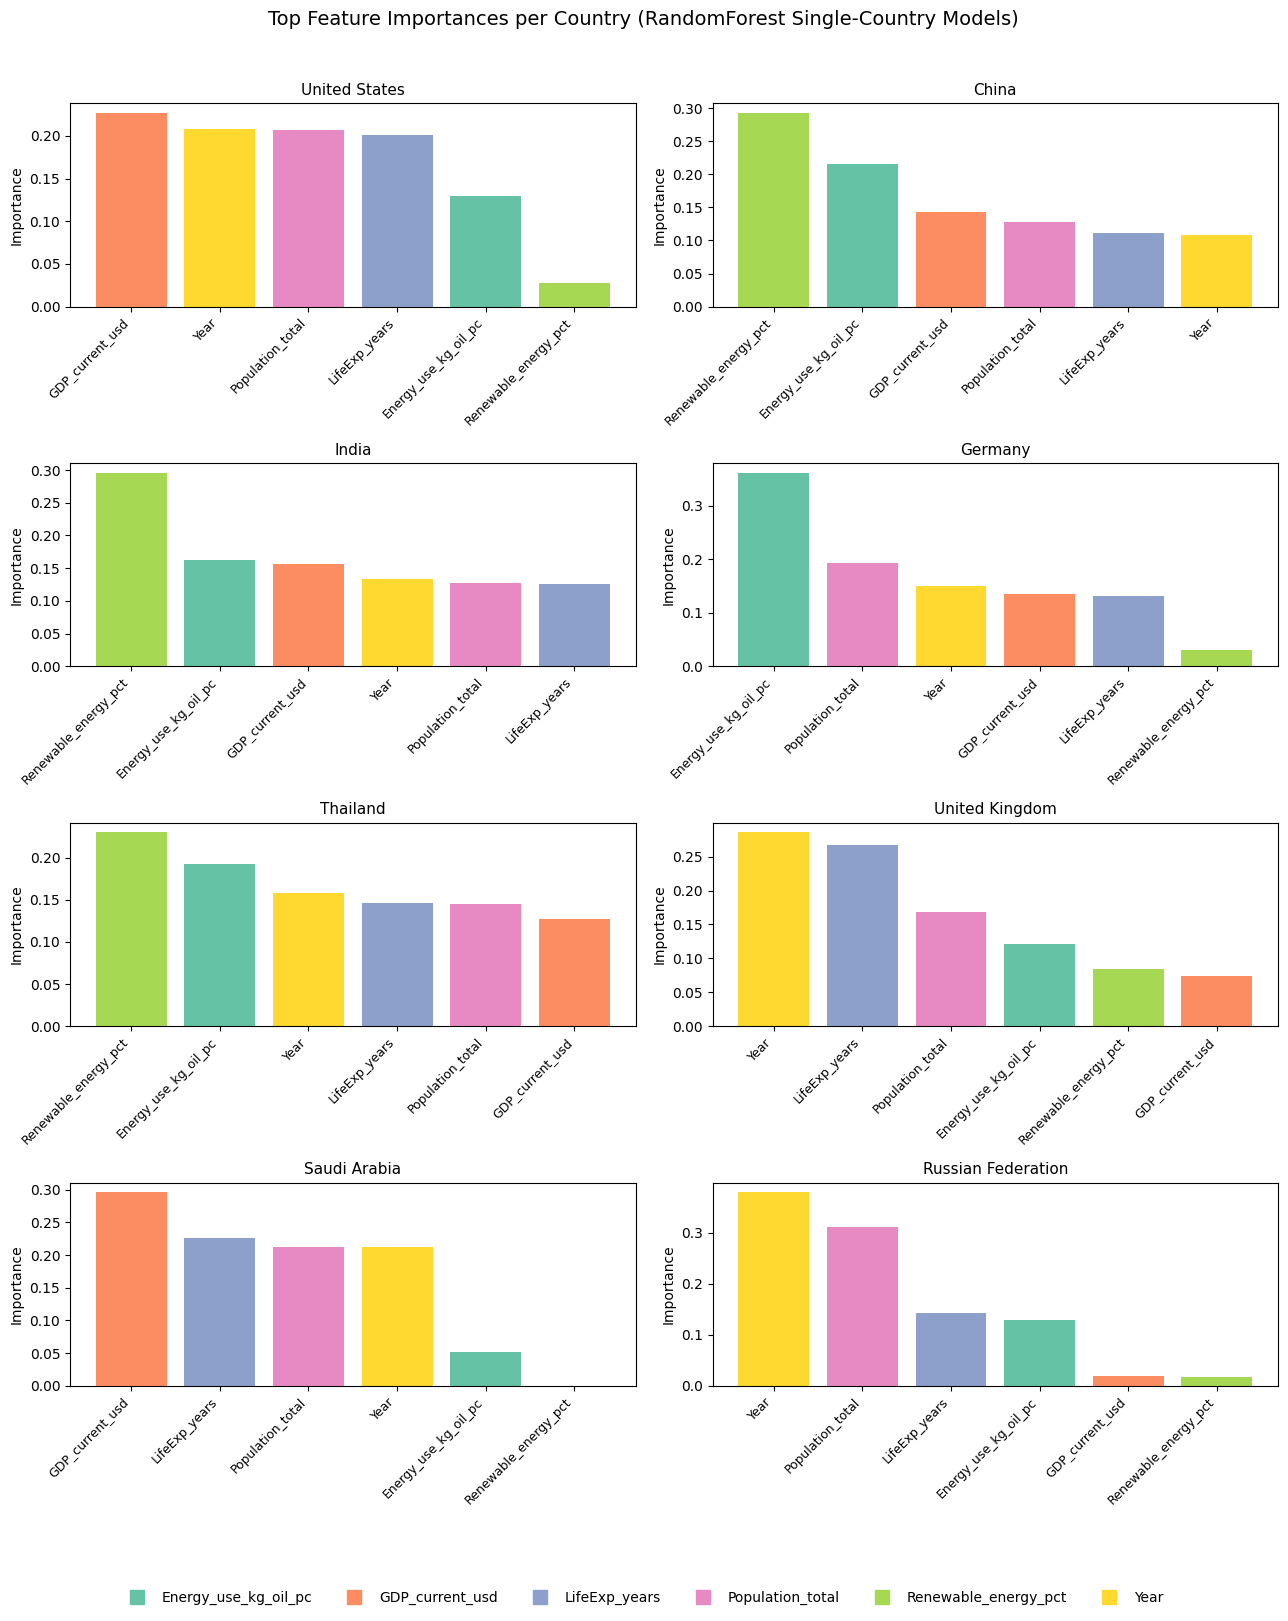

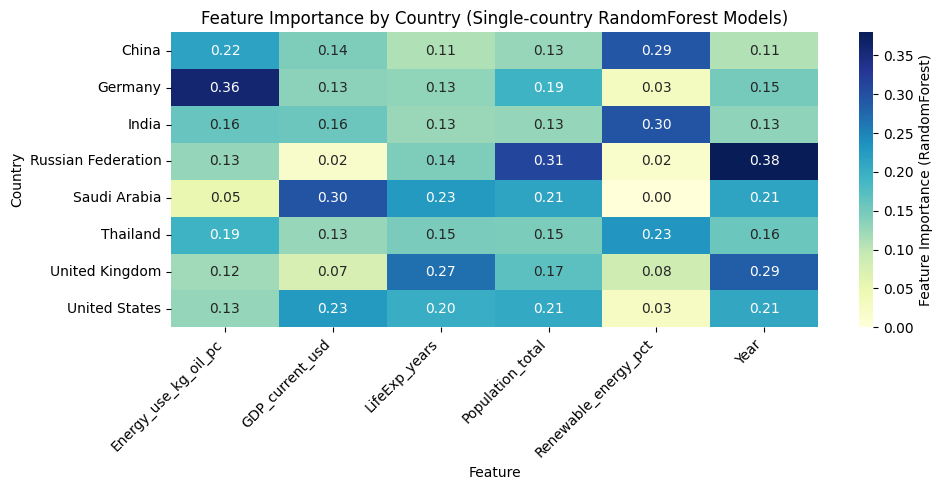

In [51]:
countries_to_plot = [c for c in focus_countries if c in pivot_imp.index]
n_countries = len(countries_to_plot)
n_cols = 2
n_rows = math.ceil(n_countries / n_cols)

feature_names = pivot_imp.columns.tolist()
colors = sns.color_palette('Set2', len(feature_names))
color_map = dict(zip(feature_names, colors))

fig, axes = plt.subplots(n_rows, n_cols,figsize=(13, 4 * n_rows),squeeze=False)

for idx, country in enumerate(countries_to_plot):
    r, c = divmod(idx, n_cols)
    ax = axes[r, c]

    imp_series = pivot_imp.loc[country].sort_values(ascending=False)
    bar_colors = [color_map[f] for f in imp_series.index]

    ax.bar(imp_series.index, imp_series.values, color=bar_colors)
    ax.set_title(country, fontsize=11)
    ax.set_ylabel('Importance')
    ax.set_xticks(range(len(imp_series)))
    ax.set_xticklabels(imp_series.index, rotation=45, ha='right', fontsize=9)
    ax.grid(False)

for j in range(idx + 1, n_rows * n_cols):
    r, c = divmod(j, n_cols)
    axes[r, c].axis('off')

legend_patches = [plt.Line2D([0], [0], marker='s', color=color_map[f], label=f, markersize=10, linestyle='') for f in feature_names]
fig.legend(handles=legend_patches,loc='lower center',ncol=len(feature_names),bbox_to_anchor=(0.5, -0.01),fontsize=10,frameon=False)

plt.suptitle('Top Feature Importances per Country (RandomForest Single-Country Models)',fontsize=14, y=0.995)
plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.show()

# heatmap
plt.figure(figsize=(10,5))
sns.heatmap(pivot_imp, annot=True, fmt='.2f', cmap='YlGnBu',
            cbar_kws={'label': 'Feature Importance (RandomForest)'})
plt.title('Feature Importance by Country (Single-country RandomForest Models)')
plt.xlabel('Feature')
plt.ylabel('Country')
plt.xticks(rotation=45, ha="right")
plt.grid(False)
plt.tight_layout()
plt.show()

> ### **Global**

------ Top feature importance (Global RandomForest) ------


,feature,importance
0,Population_total,0.337835
1,GDP_current_usd,0.256218
2,Country Code_USA,0.170160
3,Energy_use_kg_oil_pc,0.084524
4,LifeExp_years,0.057793


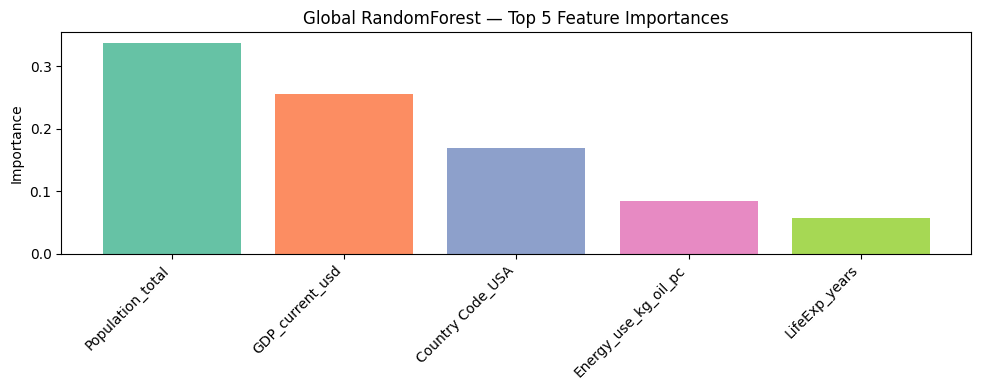

In [50]:
train_df_global = df[df['Year'] <= CUTOFF_YEAR].dropna(subset=[TARGET]).copy()
test_df_global  = df[df['Year']  > CUTOFF_YEAR].dropna(subset=[TARGET]).copy()

global_feat_cols = num_features_global + cat_features_global

X_train = train_df_global[global_feat_cols]
y_train = train_df_global[TARGET].values

X_test  = test_df_global[global_feat_cols]
y_test  = test_df_global[TARGET].values

rf_model = build_rf_global()
rf_model.fit(X_train, y_train)

rf_core = rf_model.named_steps['model']       
prep    = rf_model.named_steps['prep']       

num_cols_out = num_features_global  
cat_encoder  = prep.named_transformers_['cat']  # OneHotEncoder
cat_cols_out = list(cat_encoder.get_feature_names_out(cat_features_global))

feature_names_after = num_cols_out + cat_cols_out

importances = pd.Series(rf_core.feature_importances_,index=feature_names_after).sort_values(ascending=False)

top_k = 5
imp_top = importances.head(top_k).reset_index()
imp_top.columns = ['feature', 'importance']
print('------ Top feature importance (Global RandomForest) ------')
display(imp_top)

palette = sns.color_palette('Set2', n_colors=len(imp_top))
plt.figure(figsize=(10,4))
plt.bar(imp_top['feature'], imp_top['importance'],color=palette)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Importance')
plt.title(f'Global RandomForest — Top {top_k} Feature Importances')
plt.grid(False)
plt.tight_layout()
plt.show()